Import Liabraries



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load Dataset

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df = pd.read_csv("/content/drive/MyDrive/Processed_Flipdata - Processed_Flipdata.csv")
df

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"
...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,SAMSUNG Galaxy S23 5G,Cream,256,8,3900,50MP,12MP,0,15.49,Qualcomm Snapdragon 8 Gen 2,"79,999"
537,638,LAVA Z21,Cyan,32,2,3100,5MP,2MP,0,12.70,Octa Core,"5,998"
538,639,Tecno Spark 8T,Turquoise Cyan,64,4,5000,50MP,8MP,0,16.76,MediaTek Helio G35,"9,990"
539,641,SAMSUNG Galaxy A54 5G,Awesome Lime,128,8,5000,50MP,32MP,0,16.26,"Exynos 1380, Octa Core","38,999"


# Data Exploration

In [4]:
print(df.info())
print(df.describe())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541 entries, 0 to 540
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     541 non-null    int64  
 1   Model          541 non-null    object 
 2   Colour         541 non-null    object 
 3   Memory         541 non-null    int64  
 4   RAM            541 non-null    int64  
 5   Battery_       541 non-null    int64  
 6   Rear Camera    541 non-null    object 
 7   Front Camera   541 non-null    object 
 8   AI Lens        541 non-null    int64  
 9   Mobile Height  541 non-null    float64
 10  Processor_     541 non-null    object 
 11  Prize          541 non-null    object 
dtypes: float64(1), int64(5), object(6)
memory usage: 50.8+ KB
None
       Unnamed: 0      Memory         RAM     Battery_     AI Lens  \
count  541.000000  541.000000  541.000000   541.000000  541.000000   
mean   289.711645  110.550832    5.397412  4871.587800    0.062847   
s

# Data Preprocessing

**Handle Missing Values**: Fill missing values to avoid errors during model Training

In [5]:
# First, convert 'Prize' to numeric before one-hot encoding other columns
df['Prize'] = df['Prize'].str.replace(',', '').astype(int)

df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_15418/3882701360.py:4: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


Encode Categorical Variables: Convert text columns into numeric form

In [6]:
# Identify actual categorical columns for one-hot encoding, excluding 'Prize' and 'Unnamed: 0'
categorical_cols = df.select_dtypes(include='object').columns.tolist()
if 'Unnamed: 0' in categorical_cols:
    categorical_cols.remove('Unnamed: 0')

# Apply one-hot encoding only to the remaining categorical columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height,Prize,Model_APPLE iPhone 12,Model_APPLE iPhone 14 Plus,Model_Google Pixel 6a,...,Processor__Unisoc Spreadtrum SC9863A1,Processor__Unisoc T606,Processor__Unisoc T610,Processor__Unisoc T612,Processor__Unisoc T612 processor,Processor__Unisoc T616,Processor__Unisoc Tiger T612 (12 nm),Processor__Unisoc Tiger T616,Processor__ios,Processor__snapdragon 888
0,0,64,4,6000,1,16.76,7299,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,1,64,4,6000,1,16.76,7299,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,2,128,8,5000,0,16.64,11999,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,3,32,2,5000,0,16.56,5649,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,4,128,8,5000,1,16.76,8999,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
536,637,256,8,3900,0,15.49,79999,False,False,False,...,False,False,False,False,False,False,False,False,False,False
537,638,32,2,3100,0,12.70,5998,False,False,False,...,False,False,False,False,False,False,False,False,False,False
538,639,64,4,5000,0,16.76,9990,False,False,False,...,False,False,False,False,False,False,False,False,False,False
539,641,128,8,5000,0,16.26,38999,False,False,False,...,False,False,False,False,False,False,False,False,False,False


Remove Outliers:

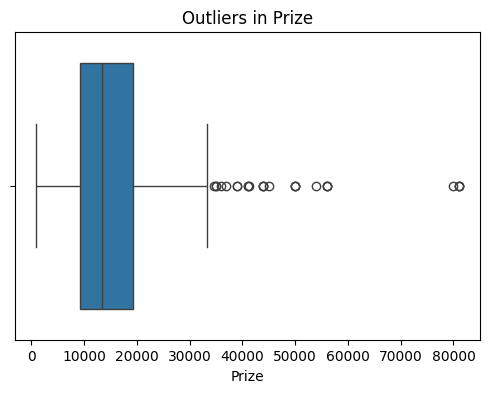

In [7]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['Prize'])
plt.title("Outliers in Prize")
plt.show()

# Feature Extraction

Correlation Heatmap: It shows the relationship between features and Price

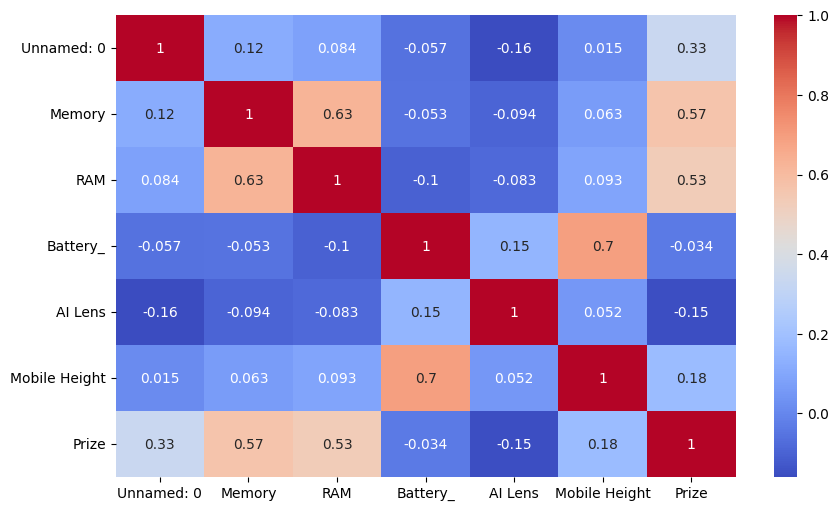

In [16]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

Feature Importance using Random Forest: It identifies most important features affecting price.

In [9]:
X = df.drop("Prize", axis=1)
y = df["Prize"]

rf_model = RandomForestRegressor()
rf_model.fit(X, y)

importance = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(importance_df)

                    Feature  Importance
1                    Memory    0.258789
480       Front Camera_12MP    0.200859
3                  Battery_    0.131438
5             Mobile Height    0.074815
2                       RAM    0.071258
..                      ...         ...
195         Colour_Aqua Sky    0.000000
256    Colour_Diamond White    0.000000
266   Colour_Fantasy Purple    0.000000
211       Colour_Azure Blue    0.000000
226  Colour_Caribbean Green    0.000000

[613 rows x 2 columns]


# Model Building

Train-Test Split: It split data into training and testing sets.

In [11]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=4)

Train Model

Linear Regression

In [12]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

Random Forest

In [13]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)

RandomForestRegressor()

# Model Evaluation

Evaluate Random Forest Model: Check how accurate the predictions are.

In [14]:
y_pred = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 2066.793577981651
RMSE: 3809.4759559519666


# Feature Importance Visualization

Visual representation of important features.

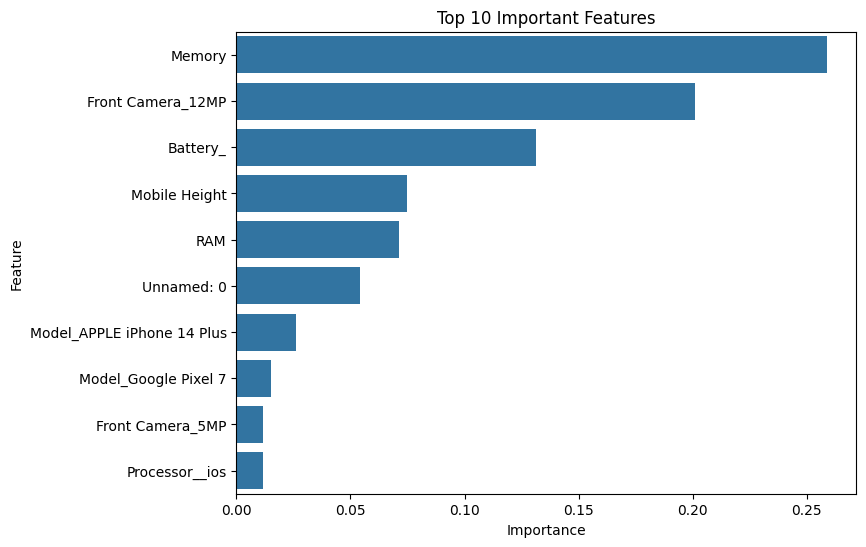

In [15]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10))
plt.title("Top 10 Important Features")
plt.show()

# Final Insights

**Based on results, We can conclude:**

     *   Features like RAM, Storage, Processor have highest impact
     *   Camera and Battery have moderate impact
     *   Color and model name have low impact
